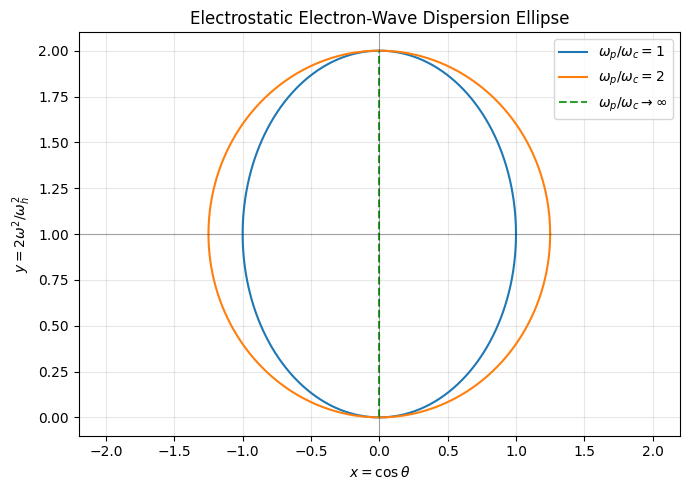

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Plot electrostatic electron-wave dispersion ellipse
(y - 1)^2 + x^2 / a^2 = 1

x = cos(theta)
y = 2 * omega^2 / omega_h^2
a = omega_h^2 / (2 * omega_c * omega_p)

Cases shown:
  omega_p / omega_c = 1, 2, infinity
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Parameter ratios to plot
# ---------------------------------------------------------------------
ratios = [1.0, 2.0, np.inf]
labels = [r"$\omega_p/\omega_c = 1$",
          r"$\omega_p/\omega_c = 2$",
          r"$\omega_p/\omega_c \to \infty$"]

# Parameter for ellipse
phi = np.linspace(0, 2*np.pi, 1000)

fig, ax = plt.subplots(figsize=(7, 5))

for ratio, label in zip(ratios, labels):

    if np.isfinite(ratio):
        # Normalize omega_c = 1
        omega_c = 1.0
        omega_p = ratio * omega_c
        omega_h2 = omega_p**2 + omega_c**2

        a = omega_h2 / (2 * omega_c * omega_p)

        # Parametric ellipse
        x = a * np.cos(phi)
        y = 1.0 + np.sin(phi)

        ax.plot(x, y, label=label)

    else:
        # omega_p / omega_c -> infinity
        # a -> infinity => x = 0, |y - 1| <= 1
        y = np.linspace(0.0, 2.0, 500)
        x = np.zeros_like(y)

        ax.plot(x, y, "--", label=label)

# ---------------------------------------------------------------------
# Plot formatting
# ---------------------------------------------------------------------
ax.axhline(1.0, color="k", alpha=0.3, linewidth=0.8)
ax.axvline(0.0, color="k", alpha=0.3, linewidth=0.8)

ax.set_xlabel(r"$x = \cos\theta$")
ax.set_ylabel(r"$y = 2\omega^2 / \omega_h^2$")

ax.set_xlim(-2.2, 2.2)
ax.set_ylim(-0.1, 2.1)

ax.set_title("Electrostatic Electron-Wave Dispersion Ellipse")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
